# MCDM Analysis for AXA Insurance "AXA PRISM"



In [ ]:
# ============================================================================
# ANALISIS KOMPARATIF METODE MCDM UNTUK SISTEM ASURANSI AXA
# Metode: SAW, EDAS, TOPSIS, AHP
# Framework: CRISP-DM
# ============================================================================



In [29]:
"""
Tahap persiapan lingkungan dan import semua library yang diperlukan
untuk analisis Multi-Criteria Decision Making (MCDM).
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
from scipy import stats

# Konfigurasi visualisasi
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="husl", font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.family'] = 'sans-serif'

# Seed untuk reproduktibilitas
np.random.seed(42)

print("="*80)
print("SISTEM PENDUKUNG KEPUTUSAN ASURANSI AXA")
print("Framework CRISP-DM - Tahap Data Preparation & Modeling")
print("="*80)
print(f"\nAnalisis dimulai pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\nLibrary yang digunakan:")
print(f"  - pandas {pd.__version__}")
print(f"  - numpy {np.__version__}")
print(f"  - matplotlib {plt.matplotlib.__version__}")
print(f"  - seaborn {sns.__version__}")
print("\n✓ Semua library berhasil dimuat")


SISTEM PENDUKUNG KEPUTUSAN ASURANSI AXA
Framework CRISP-DM - Tahap Data Preparation & Modeling

Analisis dimulai pada: 2026-05-05 05:19:57

Library yang digunakan:
  - pandas 2.3.3
  - numpy 2.4.2
  - matplotlib 3.10.8
  - seaborn 0.13.2

✓ Semua library berhasil dimuat


In [31]:
"""
Membaca data dari file CSV yang tersedia di project.
Data terdiri dari Data_Klaim.csv dan Data_Polis.csv.
"""
print("\n" + "="*80)
print("CELL 2: MEMBACA DATA DARI FILE CSV")
print("="*80)

# Load data
df_klaim = pd.read_csv('dataset\Data_Klaim.csv')
df_polis = pd.read_csv('dataset\Data_Polis.csv')

print(f"\n📊 Data Klaim: {df_klaim.shape[0]} baris x {df_klaim.shape[1]} kolom")
print(f"📊 Data Polis: {df_polis.shape[0]} baris x {df_polis.shape[1]} kolom")

print("\n--- Preview Data Klaim (5 baris pertama) ---")
print(df_klaim.head())

print("\n--- Preview Data Polis (5 baris pertama) ---")
print(df_polis.head())

print("\n--- Info Data Klaim ---")
print(df_klaim.info())

print("\n--- Info Data Polis ---")
print(df_polis.info())





CELL 2: MEMBACA DATA DARI FILE CSV

📊 Data Klaim: 4627 baris x 13 kolom
📊 Data Polis: 4096 baris x 6 kolom

--- Preview Data Klaim (5 baris pertama) ---
   Claim ID Nomor Polis Reimburse/Cashless Inpatient/Outpatient ICD Diagnosis  \
0  C-0001-M    POL-0176                  R                   OP           C50   
1  C-0002-M    POL-3288                  R                   OP           C34   
2  C-0003-M    POL-1786                  R                   OP         C18.9   
3  C-0004-M    POL-1786                  R                   OP           C34   
4  C-0005-M    POL-2778                  R                   OP           C50   

                           ICD Description Status Klaim  \
0             MALIGNANT NEOPLASM OF BREAST         PAID   
1  MALIGNANT NEOPLASM OF BRONCHUS AND LUNG         PAID   
2   MALIGNANT NEOPLASM, COLON, UNSPECIFIED         PAID   
3  MALIGNANT NEOPLASM OF BRONCHUS AND LUNG         PAID   
4             MALIGNANT NEOPLASM OF BREAST         PAID   

  Ta

In [33]:
"""
Menggabungkan data klaim dengan data polis dan melakukan feature engineering
untuk membuat kriteria yang relevan dengan analisis MCDM.
"""
print("\n" + "="*80)
print("CELL 3: DATA PREPARATION & FEATURE ENGINEERING")
print("="*80)

# Merge data klaim dan polis
df_merged = df_klaim.merge(df_polis, on='Nomor Polis', how='left')
print(f"\n✓ Data berhasil digabung: {df_merged.shape[0]} baris x {df_merged.shape[1]} kolom")

# Konversi tanggal
date_columns = ['Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 
                'Tanggal Pasien Keluar RS']
for col in date_columns:
    df_merged[col] = pd.to_datetime(df_merged[col], errors='coerce')

df_merged['Tanggal Lahir'] = pd.to_datetime(df_merged['Tanggal Lahir'].astype(str), 
                                              format='%Y%m%d', errors='coerce')
df_merged['Tanggal Efektif Polis'] = pd.to_datetime(df_merged['Tanggal Efektif Polis'].astype(str), 
                                                      format='%Y%m%d', errors='coerce')

# Feature Engineering untuk Kriteria MCDM
current_date = pd.Timestamp('2024-12-01')

# C1: Total Nominal Klaim per Polis (Cost - harus diminimalkan)
df_merged['Total_Klaim'] = df_merged['Nominal Klaim Yang Disetujui']

# C2: Frekuensi Klaim per Polis (Cost - harus diminimalkan)
freq_klaim = df_merged.groupby('Nomor Polis').size().reset_index(name='Frekuensi_Klaim')

# C3: Durasi Rawat (Cost - semakin lama semakin buruk)
df_merged['Durasi_Rawat'] = (df_merged['Tanggal Pasien Keluar RS'] - 
                              df_merged['Tanggal Pasien Masuk RS']).dt.days
df_merged['Durasi_Rawat'] = df_merged['Durasi_Rawat'].fillna(0)

# C4: Usia Pasien saat klaim (Cost - usia lebih tua = risk lebih tinggi)
df_merged['Usia_Pasien'] = ((df_merged['Tanggal Pasien Masuk RS'] - 
                              df_merged['Tanggal Lahir']).dt.days / 365.25)

# C5: Lama Kepesertaan Polis (Benefit - semakin lama semakin baik)
df_merged['Lama_Polis'] = ((current_date - df_merged['Tanggal Efektif Polis']).dt.days / 365.25)

# C6: Rasio Approval (Benefit - semakin tinggi semakin baik)
df_merged['Rasio_Approval'] = (df_merged['Nominal Klaim Yang Disetujui'] / 
                                df_merged['Nominal Biaya RS Yang Terjadi']).fillna(0)
df_merged['Rasio_Approval'] = df_merged['Rasio_Approval'].replace([np.inf, -np.inf], 0)

# Agregasi per polis untuk analisis
df_agregat = df_merged.groupby('Nomor Polis').agg({
    'Total_Klaim': 'sum',
    'Durasi_Rawat': 'mean',
    'Usia_Pasien': 'mean',
    'Lama_Polis': 'first',
    'Rasio_Approval': 'mean'
}).reset_index()

df_agregat = df_agregat.merge(freq_klaim, on='Nomor Polis', how='left')

print("\n--- Feature Engineering Summary ---")
print(f"Total polis unik: {df_agregat.shape[0]}")
print("\nKriteria yang dibuat:")
print("  C1: Total_Klaim (Cost) - Total nominal klaim yang disetujui")
print("  C2: Frekuensi_Klaim (Cost) - Jumlah klaim yang diajukan")
print("  C3: Durasi_Rawat (Cost) - Rata-rata lama rawat inap")
print("  C4: Usia_Pasien (Cost) - Rata-rata usia pasien saat klaim")
print("  C5: Lama_Polis (Benefit) - Lama kepesertaan dalam tahun")
print("  C6: Rasio_Approval (Benefit) - Rasio klaim yang disetujui")

print("\n--- Preview Data Agregat per Polis ---")
print(df_agregat.head(10))

print("\n--- Statistik Deskriptif ---")
print(df_agregat.describe())



CELL 3: DATA PREPARATION & FEATURE ENGINEERING

✓ Data berhasil digabung: 4627 baris x 18 kolom

--- Feature Engineering Summary ---
Total polis unik: 1210

Kriteria yang dibuat:
  C1: Total_Klaim (Cost) - Total nominal klaim yang disetujui
  C2: Frekuensi_Klaim (Cost) - Jumlah klaim yang diajukan
  C3: Durasi_Rawat (Cost) - Rata-rata lama rawat inap
  C4: Usia_Pasien (Cost) - Rata-rata usia pasien saat klaim
  C5: Lama_Polis (Benefit) - Lama kepesertaan dalam tahun
  C6: Rasio_Approval (Benefit) - Rasio klaim yang disetujui

--- Preview Data Agregat per Polis ---
  Nomor Polis   Total_Klaim  Durasi_Rawat  Usia_Pasien  Lama_Polis  \
0    POL-0003  1.413816e+07           1.0    45.054073    8.314853   
1    POL-0006  1.786125e+08           3.5    68.813142    8.427105   
2    POL-0010  6.497528e+07           0.0    66.621492    7.230664   
3    POL-0011  3.597431e+08           1.0    62.097194    7.025325   
4    POL-0013  1.569392e+08          10.0    53.941136    7.737166   
5    POL


CELL 4: SAMPLING DAN PEMBENTUKAN MATRIKS KEPUTUSAN

✓ Jumlah alternatif yang dianalisis: 52

--- Matriks Keputusan (X) ---
      Total_Klaim  Frekuensi_Klaim  Durasi_Rawat  Usia_Pasien  Lama_Polis  \
A01  1.214100e+07              1.0      3.000000    84.755647   11.189596   
A02  7.645200e+06              1.0      4.000000    11.572895   11.044490   
A03  9.126479e+06              1.0      3.000000     8.670773    8.862423   
A04  3.471975e+06              1.0      0.000000    36.292950   12.197125   
A05  1.946804e+07              1.0      1.000000    72.974675   10.642026   
A06  4.172700e+06              1.0      0.000000    68.517454   10.806297   
A07  6.222800e+06              1.0      1.000000    63.066393    8.533881   
A08  1.567029e+07              1.0      1.000000    61.286790   10.882957   
A09  1.210127e+07              1.0      2.000000    81.826146    7.846680   
A10  2.272940e+07              2.0      0.000000    32.388775    9.442847   
A11  1.415220e+07            

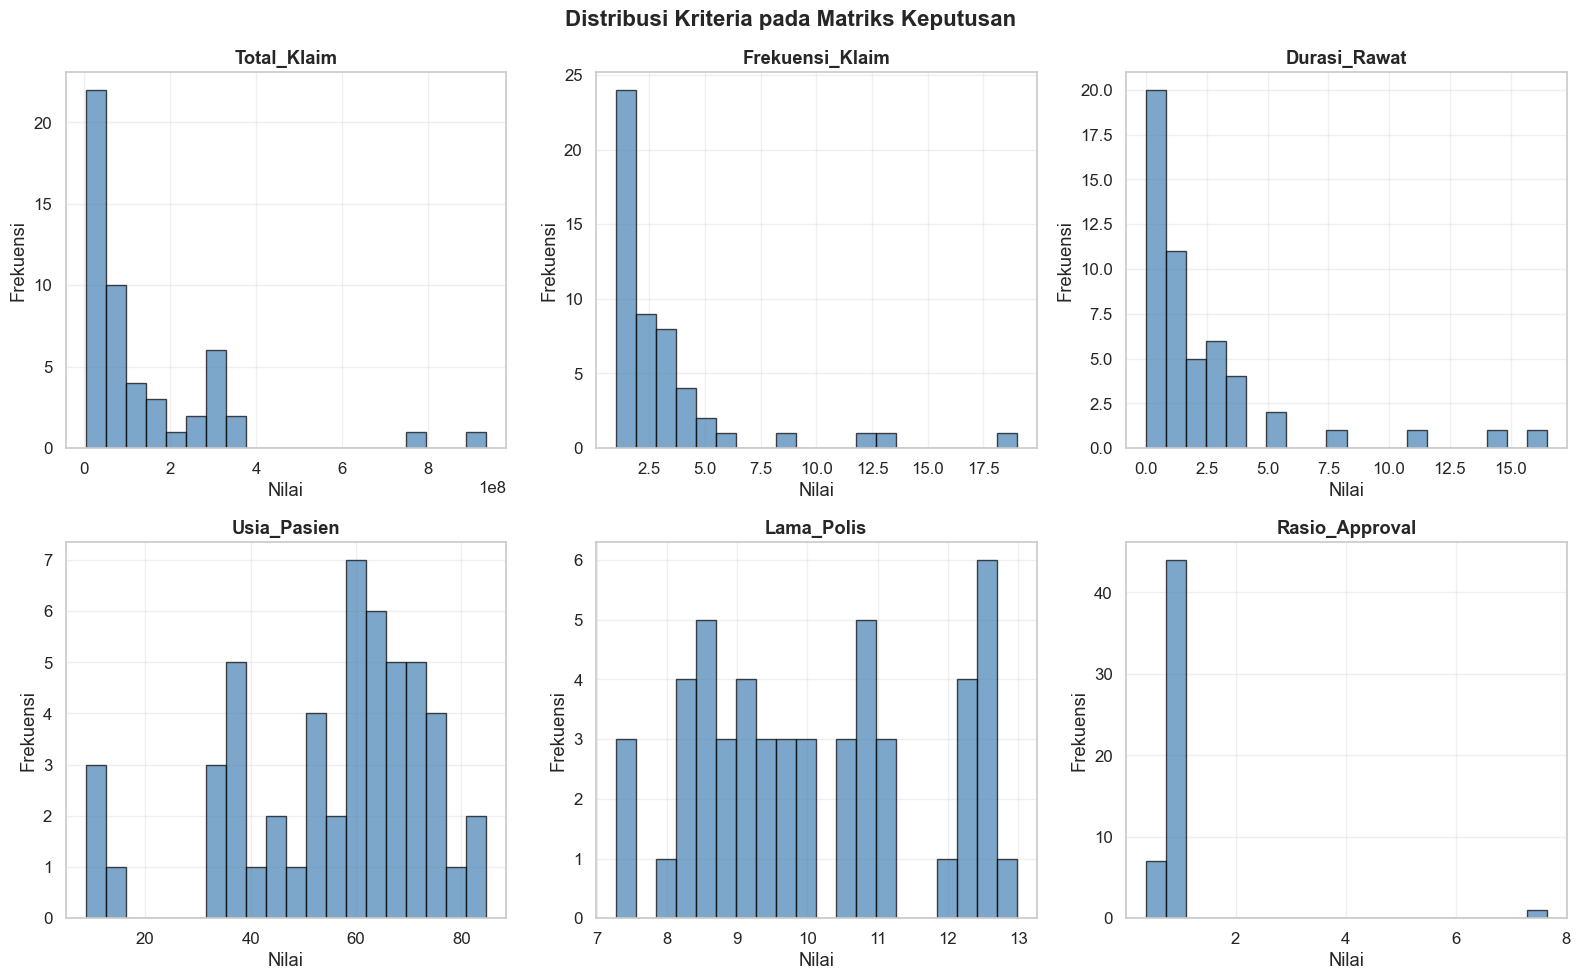

In [36]:
"""
Melakukan sampling untuk mendapatkan alternatif yang representatif
dan membentuk matriks keputusan untuk analisis MCDM.
"""
print("\n" + "="*80)
print("CELL 4: SAMPLING DAN PEMBENTUKAN MATRIKS KEPUTUSAN")
print("="*80)

# Remove missing values dan outliers ekstrem
df_clean = df_agregat.dropna()
df_clean = df_clean[df_clean['Total_Klaim'] > 0]  # Hanya polis dengan klaim

# Sampling 50 alternatif secara stratified berdasarkan kuartil total klaim
df_clean['Kuartil_Klaim'] = pd.qcut(df_clean['Total_Klaim'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Sample 12-13 dari setiap kuartil untuk total 50 alternatif
sampled_data = df_clean.groupby('Kuartil_Klaim', group_keys=False).apply(
    lambda x: x.sample(min(13, len(x)), random_state=42)
)

# Reset index dan buat ID alternatif
sampled_data = sampled_data.reset_index(drop=True)
sampled_data['Alternatif'] = [f'A{str(i+1).zfill(2)}' for i in range(len(sampled_data))]

# Buat matriks keputusan
kriteria_cols = ['Total_Klaim', 'Frekuensi_Klaim', 'Durasi_Rawat', 
                 'Usia_Pasien', 'Lama_Polis', 'Rasio_Approval']

X = sampled_data[kriteria_cols].values
alternatif_names = sampled_data['Alternatif'].values
polis_names = sampled_data['Nomor Polis'].values

# Buat DataFrame untuk matriks keputusan
df_decision = pd.DataFrame(X, columns=kriteria_cols, index=alternatif_names)
df_decision['Nomor_Polis'] = polis_names

print(f"\n✓ Jumlah alternatif yang dianalisis: {len(df_decision)}")
print("\n--- Matriks Keputusan (X) ---")
print(df_decision)

print("\n--- Statistik Matriks Keputusan ---")
print(df_decision[kriteria_cols].describe())

# Visualisasi distribusi kriteria
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribusi Kriteria pada Matriks Keputusan', fontsize=16, fontweight='bold')

for idx, col in enumerate(kriteria_cols):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df_decision[col], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure/distribusi_kriteria.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualisasi distribusi kriteria disimpan: distribusi_kriteria.png")
plt.show()




CELL 5: PENENTUAN BOBOT DAN TIPE KRITERIA

--- Konfigurasi Bobot dan Tipe Kriteria ---
Kriteria             Bobot      Tipe       Deskripsi                                         
------------------------------------------------------------------------------------------
Total_Klaim          0.25       Cost       Total nominal klaim (Rp)                          
Frekuensi_Klaim      0.20       Cost       Jumlah klaim yang diajukan                        
Durasi_Rawat         0.15       Cost       Rata-rata lama rawat (hari)                       
Usia_Pasien          0.15       Cost       Rata-rata usia pasien (tahun)                     
Lama_Polis           0.15       Benefit    Lama kepesertaan (tahun)                          
Rasio_Approval       0.10       Benefit    Rasio klaim disetujui                             

Total bobot: 1.00

✓ Konfigurasi bobot valid

✓ Visualisasi bobot disimpan: bobot_kriteria.png


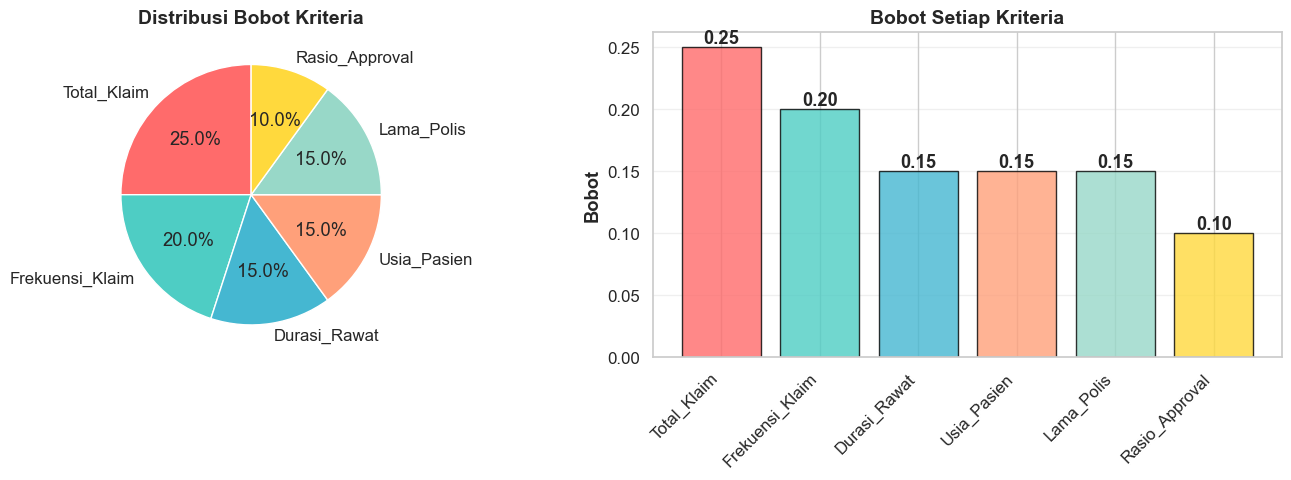

In [38]:
"""
Menentukan bobot untuk setiap kriteria dan tipe kriteria (Cost/Benefit).
Bobot ditentukan berdasarkan analisis domain asuransi.
"""
print("\n" + "="*80)
print("CELL 5: PENENTUAN BOBOT DAN TIPE KRITERIA")
print("="*80)

# Definisi bobot (total = 1.0)
weights = np.array([0.25, 0.20, 0.15, 0.15, 0.15, 0.10])

# Tipe kriteria: True = Benefit (max), False = Cost (min)
criteria_type = np.array([False, False, False, False, True, True])

# Mapping kriteria
criteria_mapping = {
    'Total_Klaim': {'weight': 0.25, 'type': 'Cost', 'desc': 'Total nominal klaim (Rp)'},
    'Frekuensi_Klaim': {'weight': 0.20, 'type': 'Cost', 'desc': 'Jumlah klaim yang diajukan'},
    'Durasi_Rawat': {'weight': 0.15, 'type': 'Cost', 'desc': 'Rata-rata lama rawat (hari)'},
    'Usia_Pasien': {'weight': 0.15, 'type': 'Cost', 'desc': 'Rata-rata usia pasien (tahun)'},
    'Lama_Polis': {'weight': 0.15, 'type': 'Benefit', 'desc': 'Lama kepesertaan (tahun)'},
    'Rasio_Approval': {'weight': 0.10, 'type': 'Benefit', 'desc': 'Rasio klaim disetujui'}
}

# Tampilkan informasi bobot
print("\n--- Konfigurasi Bobot dan Tipe Kriteria ---")
print(f"{'Kriteria':<20} {'Bobot':<10} {'Tipe':<10} {'Deskripsi':<50}")
print("-" * 90)
for i, col in enumerate(kriteria_cols):
    info = criteria_mapping[col]
    print(f"{col:<20} {info['weight']:<10.2f} {info['type']:<10} {info['desc']:<50}")

print(f"\nTotal bobot: {sum(weights):.2f}")
print("\n✓ Konfigurasi bobot valid")

# Visualisasi bobot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart bobot
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#FFD93D']
ax1.pie(weights, labels=kriteria_cols, autopct='%1.1f%%', startangle=90, colors=colors)
ax1.set_title('Distribusi Bobot Kriteria', fontweight='bold', fontsize=14)

# Bar chart bobot
bars = ax2.bar(range(len(kriteria_cols)), weights, color=colors, edgecolor='black', alpha=0.8)
ax2.set_xticks(range(len(kriteria_cols)))
ax2.set_xticklabels(kriteria_cols, rotation=45, ha='right')
ax2.set_ylabel('Bobot', fontweight='bold')
ax2.set_title('Bobot Setiap Kriteria', fontweight='bold', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Tambahkan nilai di atas bar
for i, (bar, weight) in enumerate(zip(bars, weights)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{weight:.2f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('figure/bobot_kriteria.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualisasi bobot disimpan: bobot_kriteria.png")
plt.show()



In [ ]:
"""
Simple Additive Weighting (SAW) - Tahap Normalisasi
Normalisasi dilakukan berdasarkan tipe kriteria:
- Benefit: r_ij = x_ij / max(x_j)
- Cost: r_ij = min(x_j) / x_ij
"""
print("\n" + "="*80)
print("METODE 1: SIMPLE ADDITIVE WEIGHTING (SAW)")
print("="*80)
print("\n--- TAHAP 1: NORMALISASI MATRIKS KEPUTUSAN ---")

# Inisialisasi matriks normalisasi
R_saw = np.zeros_like(X, dtype=float)

# Normalisasi untuk setiap kriteria
for j in range(X.shape[1]):
    col = X[:, j].astype(float)
    if criteria_type[j]:  # Benefit (maximize)
        max_val = np.max(col)
        R_saw[:, j] = col / max_val if max_val != 0 else 0.0
    else:  # Cost (minimize)
        min_val = np.min(col)
        max_val = np.max(col)
        if max_val == min_val:
            R_saw[:, j] = 1.0
        else:
            R_saw[:, j] = (max_val - col) / (max_val - min_val)

# Buat DataFrame untuk matriks normalisasi
df_norm_saw = pd.DataFrame(R_saw, columns=kriteria_cols, index=alternatif_names)

print("\n--- Matriks Normalisasi SAW (R) ---")
print(df_norm_saw)

print("\n--- Statistik Matriks Normalisasi ---")
print(df_norm_saw.describe())

# Validasi normalisasi (semua nilai harus 0-1)
print(f"\n✓ Rentang nilai normalisasi: [{R_saw.min():.4f}, {R_saw.max():.4f}]")
print(f"✓ Semua nilai dalam rentang [0, 1]: {(R_saw >= 0).all() and (R_saw <= 1).all()}")



METODE 1: SIMPLE ADDITIVE WEIGHTING (SAW)

--- TAHAP 1: NORMALISASI MATRIKS KEPUTUSAN ---

--- Matriks Normalisasi SAW (R) ---
     Total_Klaim  Frekuensi_Klaim  Durasi_Rawat  Usia_Pasien  Lama_Polis  \
A01     0.285971         1.000000           0.0     0.102303    0.862054   
A02     0.454138         1.000000           0.0     0.749231    0.850875   
A03     0.380429         1.000000           0.0     1.000000    0.682767   
A04     1.000000         1.000000           NaN     0.238911    0.939675   
A05     0.178342         1.000000           0.0     0.118819    0.819869   
A06     0.832069         1.000000           NaN     0.126548    0.832525   
A07     0.557944         1.000000           0.0     0.137486    0.657456   
A08     0.221564         1.000000           0.0     0.141479    0.838431   
A09     0.286910         1.000000           0.0     0.105966    0.604514   
A10     0.152753         0.500000           NaN     0.267709    0.727484   
A11     0.245331         1.000000   


--- TAHAP 2: PERHITUNGAN NILAI PREFERENSI ---

--- Hasil Ranking SAW (Top 20) ---
Alternatif Nomor_Polis  Nilai_Preferensi  Ranking_SAW
       A02    POL-3030          0.566417            1
       A03    POL-1625          0.560572            2
       A07    POL-1707          0.469584            3
       A28    POL-3180          0.454943            4
       A01    POL-2513          0.425172            5
       A16    POL-1510          0.423144            6
       A08    POL-3008          0.411372            7
       A25    POL-1404          0.402992            8
       A05    POL-0835          0.399179            9
       A09    POL-3605          0.390718           10
       A35    POL-3719          0.385671           11
       A20    POL-1554          0.367063           12
       A42    POL-1448          0.363235           13
       A48    POL-3661          0.362987           14
       A38    POL-1309          0.357563           15
       A23    POL-0430          0.357211           16

AttributeError: 'numpy.ndarray' object has no attribute 'median'

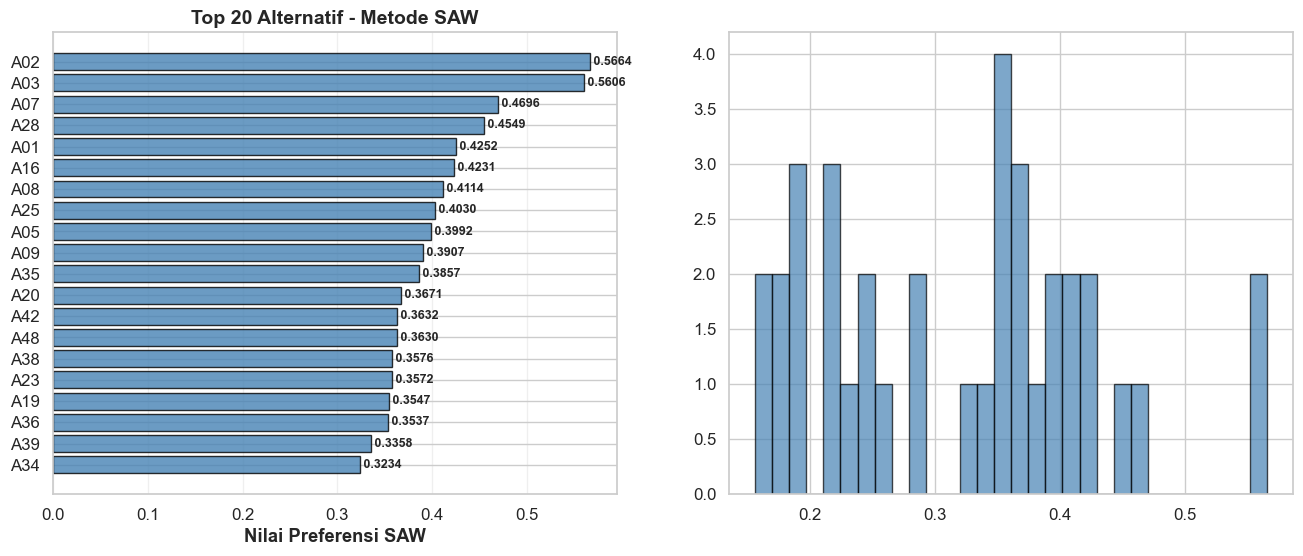

In [41]:
"""
Menghitung nilai preferensi akhir dengan mengalikan matriks normalisasi
dengan bobot kriteria: V = R × W
"""
print("\n--- TAHAP 2: PERHITUNGAN NILAI PREFERENSI ---")

# Hitung nilai preferensi (weighted sum)
V_saw = np.sum(R_saw * weights, axis=1)

# Buat DataFrame hasil
df_saw_results = pd.DataFrame({
    'Alternatif': alternatif_names,
    'Nomor_Polis': polis_names,
    'Nilai_Preferensi': V_saw
})

# Sorting berdasarkan nilai preferensi (descending)
df_saw_results = df_saw_results.sort_values('Nilai_Preferensi', ascending=False).reset_index(drop=True)
df_saw_results['Ranking_SAW'] = range(1, len(df_saw_results) + 1)

print("\n--- Hasil Ranking SAW (Top 20) ---")
print(df_saw_results.head(20).to_string(index=False))

print(f"\n--- Statistik Nilai Preferensi SAW ---")
print(f"  Nilai tertinggi: {V_saw.max():.6f} (Alternatif: {df_saw_results.iloc[0]['Alternatif']})")
print(f"  Nilai terendah: {V_saw.min():.6f} (Alternatif: {df_saw_results.iloc[-1]['Alternatif']})")
print(f"  Rata-rata: {V_saw.mean():.6f}")
print(f"  Standar deviasi: {V_saw.std():.6f}")

# Visualisasi hasil SAW
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart top 20
top_20 = df_saw_results.head(20)
bars = ax1.barh(range(len(top_20)), top_20['Nilai_Preferensi'], 
                color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20['Alternatif'])
ax1.set_xlabel('Nilai Preferensi SAW', fontweight='bold')
ax1.set_title('Top 20 Alternatif - Metode SAW', fontweight='bold', fontsize=14)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Tambahkan nilai
for i, (idx, row) in enumerate(top_20.iterrows()):
    ax1.text(row['Nilai_Preferensi'], i, f" {row['Nilai_Preferensi']:.4f}", 
             va='center', fontweight='bold', fontsize=9)

# Histogram distribusi nilai
ax2.hist(V_saw, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(V_saw.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {V_saw.mean():.4f}')
ax2.axvline(V_saw.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {V_saw.median():.4f}')
ax2.set_xlabel('Nilai Preferensi', fontweight='bold')
ax2.set_ylabel('Frekuensi', fontweight='bold')
ax2.set_title('Distribusi Nilai Preferensi SAW', fontweight='bold', fontsize=14)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figure/hasil_saw.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualisasi hasil SAW disimpan: hasil_saw.png")
plt.show()

In [16]:
"""
EDAS (Evaluation based on Distance from Average Solution)
Tahap 1: Menghitung Average Solution (AV) untuk setiap kriteria
"""
print("\n" + "="*80)
print("METODE 2: EVALUATION BASED ON DISTANCE FROM AVERAGE SOLUTION (EDAS)")
print("="*80)
print("\n--- TAHAP 1: PERHITUNGAN AVERAGE SOLUTION (AV) ---")

# Hitung average solution
AV = np.mean(X, axis=0)

# Buat DataFrame untuk AV
df_av = pd.DataFrame({
    'Kriteria': kriteria_cols,
    'Average_Value': AV,
    'Type': list(criteria_kind)
})

print("\n--- Average Solution (AV) ---")
print(df_av.to_string(index=False))





METODE 2: EVALUATION BASED ON DISTANCE FROM AVERAGE SOLUTION (EDAS)

--- TAHAP 1: PERHITUNGAN AVERAGE SOLUTION (AV) ---

--- Average Solution (AV) ---
         Kriteria  Average_Value    Type
  C01_Total_Klaim   1.642870e+08    Cost
   C02_Mean_Klaim   5.539563e+07    Cost
    C03_Max_Klaim   1.146346e+08    Cost
    C04_Std_Klaim   4.856129e+07    Cost
C05_Total_BiayaRS   1.749920e+08    Cost
C06_CostPerDayLOS   2.522476e+07    Cost
    C07_TotalFreq   3.237500e+00    Cost
  C08_FreqPerYear   3.255255e-01    Cost
 C09_PctInpatient   7.153950e+01    Cost
C10_PctOutpatient   2.846050e+01 Benefit
  C11_PctCashless   4.232278e+01 Benefit
C12_PctReim burse   5.767722e+01    Cost
       C13_AvgLOS   1.833542e+00    Cost
       C14_MaxLOS   2.625000e+00    Cost
   C15_UniqueDiag   1.925000e+00    Cost
 C16_HighRiskFreq   4.125000e-01    Cost
 C17_ComplexScore   5.826840e-01    Cost
 C18_ApprovalRate   9.435134e+01 Benefit
  C19_ProcessDays   6.783138e+01 Benefit
  C20_BenefitUtil   9.435134

In [17]:
"""
Tahap 2: Menghitung Positive Distance from Average (PDA) dan
Negative Distance from Average (NDA)
"""
print("\n--- TAHAP 2: PERHITUNGAN PDA DAN NDA ---")

# Inisialisasi PDA dan NDA
PDA = np.zeros_like(X, dtype=float)
NDA = np.zeros_like(X, dtype=float)

# Hitung PDA dan NDA untuk setiap kriteria
eps_av = 1e-12
for j in range(X.shape[1]):
    denom = max(abs(AV[j]), eps_av)
    k = criteria_kind[j]
    if k == 'Benefit':
        PDA[:, j] = np.maximum(0, (X[:, j] - AV[j])) / denom
        NDA[:, j] = np.maximum(0, (AV[j] - X[:, j])) / denom
    elif k == 'Cost':
        PDA[:, j] = np.maximum(0, (AV[j] - X[:, j])) / denom
        NDA[:, j] = np.maximum(0, (X[:, j] - AV[j])) / denom
    else:
        PDA[:, j] = 0.0
        NDA[:, j] = 0.0

# Buat DataFrame untuk PDA dan NDA
df_pda = pd.DataFrame(PDA, columns=kriteria_cols, index=alternatif_names)
df_nda = pd.DataFrame(NDA, columns=kriteria_cols, index=alternatif_names)

print("\n--- Positive Distance from Average (PDA) - Sample 10 alternatif ---")
print(df_pda.head(10))

print("\n--- Negative Distance from Average (NDA) - Sample 10 alternatif ---")
print(df_nda.head(10))





--- TAHAP 2: PERHITUNGAN PDA DAN NDA ---

--- Positive Distance from Average (PDA) - Sample 10 alternatif ---
     C01_Total_Klaim  C02_Mean_Klaim  C03_Max_Klaim  C04_Std_Klaim  \
A01         0.925734        0.779751       0.893567        1.00000   
A02         0.906769        0.723504       0.866387        1.00000   
A03         0.900734        0.705608       0.857739        1.00000   
A04         0.871094        0.617703       0.815260        1.00000   
A05         0.909942        0.732914       0.870935        1.00000   
A06         0.983590        0.951334       0.976483        1.00000   
A07         0.855797        0.572337       0.793338        1.00000   
A08         0.897004        0.694545       0.852393        1.00000   
A09         0.907924        0.863465       0.931062        0.99012   
A10         0.867332        0.606545       0.809868        1.00000   

     C05_Total_BiayaRS  C06_CostPerDayLOS  C07_TotalFreq  C08_FreqPerYear  \
A01           0.930278           0.516314

In [18]:
"""
Tahap 3: Menghitung weighted sum SP dan SN, kemudian normalisasi
"""
print("\n--- TAHAP 3: WEIGHTED SUM DAN NORMALISASI ---")

# Hitung weighted sum
SP = np.sum(PDA * weights, axis=1)
SN = np.sum(NDA * weights, axis=1)

# Normalisasi SP dan SN
NSP = SP / np.max(SP)
NSN = 1 - (SN / np.max(SN))

print(f"\n--- Statistik SP (Sum of PDA) ---")
print(f"  Max: {SP.max():.6f}")
print(f"  Min: {SP.min():.6f}")
print(f"  Mean: {SP.mean():.6f}")

print(f"\n--- Statistik SN (Sum of NDA) ---")
print(f"  Max: {SN.max():.6f}")
print(f"  Min: {SN.min():.6f}")
print(f"  Mean: {SN.mean():.6f}")

# Buat DataFrame sementara
df_edas_temp = pd.DataFrame({
    'Alternatif': alternatif_names,
    'SP': SP,
    'SN': SN,
    'NSP': NSP,
    'NSN': NSN
})

print("\n--- Hasil Normalisasi (NSP dan NSN) - Sample 10 alternatif ---")
print(df_edas_temp.head(10).to_string(index=False))





--- TAHAP 3: WEIGHTED SUM DAN NORMALISASI ---

--- Statistik SP (Sum of PDA) ---
  Max: 0.754569
  Min: 0.008232
  Mean: 0.413816

--- Statistik SN (Sum of NDA) ---
  Max: 2.869019
  Min: 0.008716
  Mean: 0.413816

--- Hasil Normalisasi (NSP dan NSN) - Sample 10 alternatif ---
Alternatif       SP       SN      NSP      NSN
       A01 0.550912 0.159117 0.730102 0.944540
       A02 0.600722 0.074431 0.796113 0.974057
       A03 0.754569 0.086689 1.000000 0.969784
       A04 0.494001 0.165257 0.654680 0.942399
       A05 0.590960 0.082477 0.783176 0.971253
       A06 0.698800 0.082838 0.926093 0.971127
       A07 0.470739 0.171001 0.623851 0.940398
       A08 0.667959 0.070327 0.885219 0.975487
       A09 0.544149 0.100062 0.721139 0.965123
       A10 0.731113 0.095997 0.968915 0.966540



--- TAHAP 4: APPRAISAL SCORE DAN RANKING ---

--- Hasil Ranking EDAS (Top 20) ---
Alternatif Nomor_Polis  Appraisal_Score  Ranking_EDAS
       A03    POL-0845         0.984892             1
       A12    POL-0058         0.972271             2
       A11    POL-3034         0.970905             3
       A19    POL-3064         0.969992             4
       A10    POL-1653         0.967728             5
       A06    POL-4092         0.948610             6
       A08    POL-2366         0.930353             7
       A15    POL-3473         0.917423             8
       A51    POL-0817         0.904126             9
       A02    POL-0960         0.885085            10
       A18    POL-0134         0.878307            11
       A05    POL-1294         0.877214            12
       A28    POL-0533         0.874726            13
       A14    POL-1043         0.873619            14
       A21    POL-3323         0.870732            15
       A33    POL-2851         0.863709            16

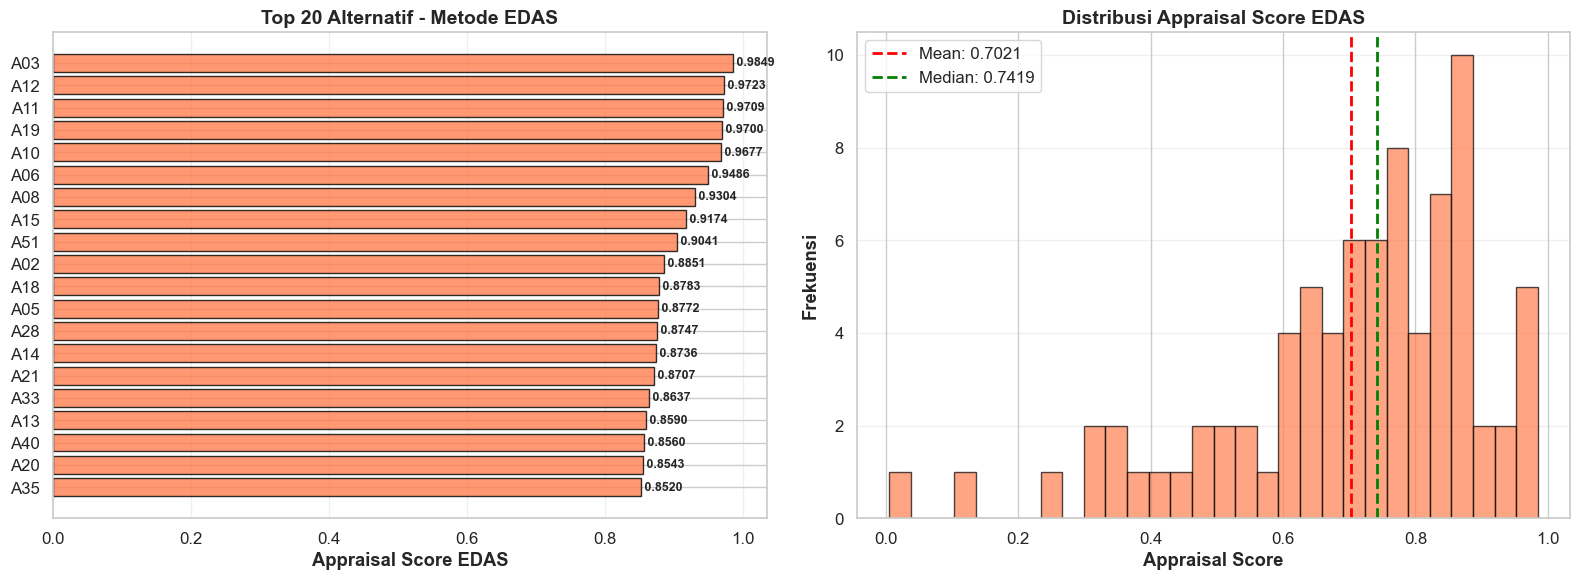

In [19]:
"""
Tahap 4: Menghitung Appraisal Score (AS) dan ranking final
AS = (NSP + NSN) / 2
"""
print("\n--- TAHAP 4: APPRAISAL SCORE DAN RANKING ---")

# Hitung Appraisal Score
AS = (NSP + NSN) / 2

# Buat DataFrame hasil
df_edas_results = pd.DataFrame({
    'Alternatif': alternatif_names,
    'Nomor_Polis': polis_names,
    'Appraisal_Score': AS
})

# Sorting berdasarkan appraisal score (descending)
df_edas_results = df_edas_results.sort_values('Appraisal_Score', ascending=False).reset_index(drop=True)
df_edas_results['Ranking_EDAS'] = range(1, len(df_edas_results) + 1)

print("\n--- Hasil Ranking EDAS (Top 20) ---")
print(df_edas_results.head(20).to_string(index=False))

print(f"\n--- Statistik Appraisal Score ---")
print(f"  Nilai tertinggi: {AS.max():.6f} (Alternatif: {df_edas_results.iloc[0]['Alternatif']})")
print(f"  Nilai terendah: {AS.min():.6f} (Alternatif: {df_edas_results.iloc[-1]['Alternatif']})")
print(f"  Rata-rata: {AS.mean():.6f}")
print(f"  Standar deviasi: {AS.std():.6f}")

# Visualisasi hasil EDAS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart top 20
top_20 = df_edas_results.head(20)
bars = ax1.barh(range(len(top_20)), top_20['Appraisal_Score'], 
                color='coral', edgecolor='black', alpha=0.8)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20['Alternatif'])
ax1.set_xlabel('Appraisal Score EDAS', fontweight='bold')
ax1.set_title('Top 20 Alternatif - Metode EDAS', fontweight='bold', fontsize=14)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Tambahkan nilai
for i, (idx, row) in enumerate(top_20.iterrows()):
    ax1.text(row['Appraisal_Score'], i, f" {row['Appraisal_Score']:.4f}", 
             va='center', fontweight='bold', fontsize=9)

# Histogram distribusi nilai
ax2.hist(AS, bins=30, color='coral', alpha=0.7, edgecolor='black')
ax2.axvline(AS.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {AS.mean():.4f}')
ax2.axvline(np.median(AS), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(AS):.4f}')
ax2.set_xlabel('Appraisal Score', fontweight='bold')
ax2.set_ylabel('Frekuensi', fontweight='bold')
ax2.set_title('Distribusi Appraisal Score EDAS', fontweight='bold', fontsize=14)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hasil_edas.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualisasi hasil EDAS disimpan: hasil_edas.png")
plt.show()




In [20]:
"""
TOPSIS (Technique for Order Preference by Similarity to Ideal Solution)
Tahap 1: Normalisasi dengan metode vector (membagi dengan akar jumlah kuadrat)
"""
print("\n" + "="*80)
print("METODE 3: TECHNIQUE FOR ORDER PREFERENCE BY SIMILARITY TO IDEAL SOLUTION (TOPSIS)")
print("="*80)
print("\n--- TAHAP 1: NORMALISASI VECTOR ---")

# Hitung normalisasi vector
sum_squares = np.sqrt(np.sum(X**2, axis=0))
R_topsis = X / sum_squares

# Buat DataFrame untuk matriks normalisasi
df_norm_topsis = pd.DataFrame(R_topsis, columns=kriteria_cols, index=alternatif_names)

print("\n--- Matriks Normalisasi TOPSIS (R) - Sample 10 alternatif ---")
print(df_norm_topsis.head(10))

print("\n--- Statistik Matriks Normalisasi ---")
print(df_norm_topsis.describe())





METODE 3: TECHNIQUE FOR ORDER PREFERENCE BY SIMILARITY TO IDEAL SOLUTION (TOPSIS)

--- TAHAP 1: NORMALISASI VECTOR ---

--- Matriks Normalisasi TOPSIS (R) - Sample 10 alternatif ---
     C01_Total_Klaim  C02_Mean_Klaim  C03_Max_Klaim  C04_Std_Klaim  \
A01         0.004639        0.013198       0.006329       0.000000   
A02         0.005824        0.016568       0.007946       0.000000   
A03         0.006201        0.017641       0.008460       0.000000   
A04         0.008053        0.022908       0.010986       0.000000   
A05         0.005626        0.016004       0.007675       0.000000   
A06         0.001025        0.002916       0.001398       0.000000   
A07         0.009008        0.025627       0.012290       0.000000   
A08         0.006434        0.018304       0.008778       0.000000   
A09         0.005752        0.008182       0.004100       0.000528   
A10         0.008288        0.023577       0.011307       0.000000   

     C05_Total_BiayaRS  C06_CostPerDayLOS  C07

In [21]:
"""
Tahap 2: Menghitung matriks normalisasi terbobot
Y = R × W (element-wise multiplication)
"""
print("\n--- TAHAP 2: MATRIKS NORMALISASI TERBOBOT ---")

# Hitung matriks terbobot
Y = R_topsis * weights

# Buat DataFrame
df_weighted_topsis = pd.DataFrame(Y, columns=kriteria_cols, index=alternatif_names)

print("\n--- Matriks Normalisasi Terbobot (Y) - Sample 10 alternatif ---")
print(df_weighted_topsis.head(10))

print("\n--- Statistik Matriks Terbobot ---")
print(df_weighted_topsis.describe())





--- TAHAP 2: MATRIKS NORMALISASI TERBOBOT ---

--- Matriks Normalisasi Terbobot (Y) - Sample 10 alternatif ---
     C01_Total_Klaim  C02_Mean_Klaim  C03_Max_Klaim  C04_Std_Klaim  \
A01         0.000232        0.000660       0.000316       0.000000   
A02         0.000291        0.000828       0.000397       0.000000   
A03         0.000310        0.000882       0.000423       0.000000   
A04         0.000403        0.001145       0.000549       0.000000   
A05         0.000281        0.000800       0.000384       0.000000   
A06         0.000051        0.000146       0.000070       0.000000   
A07         0.000450        0.001281       0.000614       0.000000   
A08         0.000322        0.000915       0.000439       0.000000   
A09         0.000288        0.000409       0.000205       0.000026   
A10         0.000414        0.001179       0.000565       0.000000   

     C05_Total_BiayaRS  C06_CostPerDayLOS  C07_TotalFreq  C08_FreqPerYear  \
A01           0.000219           0.00142

In [22]:
"""
Tahap 3: Menentukan Solusi Ideal Positif (A+) dan Solusi Ideal Negatif (A-)
A+ = nilai terbaik untuk setiap kriteria
A- = nilai terburuk untuk setiap kriteria
"""
print("\n--- TAHAP 3: SOLUSI IDEAL POSITIF DAN NEGATIF ---")

# Inisialisasi A+ dan A-
A_plus = np.zeros(X.shape[1])
A_minus = np.zeros(X.shape[1])

# Tentukan A+ dan A- untuk setiap kriteria
for j in range(X.shape[1]):
    k = criteria_kind[j]
    if k == 'Benefit' or k == 'Neutral':
        A_plus[j] = np.max(Y[:, j])
        A_minus[j] = np.min(Y[:, j])
    else:
        A_plus[j] = np.min(Y[:, j])
        A_minus[j] = np.max(Y[:, j])

# Buat DataFrame untuk A+ dan A-
df_ideal = pd.DataFrame({
    'Kriteria': kriteria_cols,
    'A_Plus': A_plus,
    'A_Minus': A_minus,
    'Type': list(criteria_kind)
})

print("\n--- Solusi Ideal Positif (A+) dan Negatif (A-) ---")
print(df_ideal.to_string(index=False))





--- TAHAP 3: SOLUSI IDEAL POSITIF DAN NEGATIF ---

--- Solusi Ideal Positif (A+) dan Negatif (A-) ---
         Kriteria   A_Plus  A_Minus    Type
  C01_Total_Klaim 0.000051 0.028469    Cost
   C02_Mean_Klaim 0.000117 0.025978    Cost
    C03_Max_Klaim 0.000070 0.027388    Cost
    C04_Std_Klaim 0.000000 0.027355    Cost
C05_Total_BiayaRS 0.000048 0.027506    Cost
C06_CostPerDayLOS 0.000000 0.033159    Cost
    C07_TotalFreq 0.001349 0.018891    Cost
  C08_FreqPerYear 0.001048 0.023390    Cost
 C09_PctInpatient 0.000000 0.006985    Cost
C10_PctOutpatient 0.012208 0.000000 Benefit
  C11_PctCashless 0.009323 0.000000 Benefit
C12_PctReim burse 0.000000 0.007804    Cost
       C13_AvgLOS 0.000000 0.036390    Cost
       C14_MaxLOS 0.000000 0.032183    Cost
   C15_UniqueDiag 0.002494 0.012469    Cost
 C16_HighRiskFreq 0.000000 0.034044    Cost
 C17_ComplexScore 0.000000 0.025723    Cost
 C18_ApprovalRate 0.003279 0.001729 Benefit
  C19_ProcessDays 0.007866 0.000938 Benefit
  C20_BenefitUtil


--- TAHAP 4: JARAK DAN NILAI PREFERENSI ---

--- Hasil Ranking TOPSIS (Top 20) ---
Alternatif Nomor_Polis  Nilai_Preferensi  Ranking_TOPSIS
       A01    POL-2941               NaN               1
       A02    POL-0960               NaN               2
       A03    POL-0845               NaN               3
       A04    POL-0368               NaN               4
       A05    POL-1294               NaN               5
       A06    POL-4092               NaN               6
       A07    POL-1044               NaN               7
       A08    POL-2366               NaN               8
       A09    POL-3464               NaN               9
       A10    POL-1653               NaN              10
       A11    POL-3034               NaN              11
       A12    POL-0058               NaN              12
       A13    POL-3645               NaN              13
       A14    POL-1043               NaN              14
       A15    POL-3473               NaN              15
    

ValueError: autodetected range of [nan, nan] is not finite

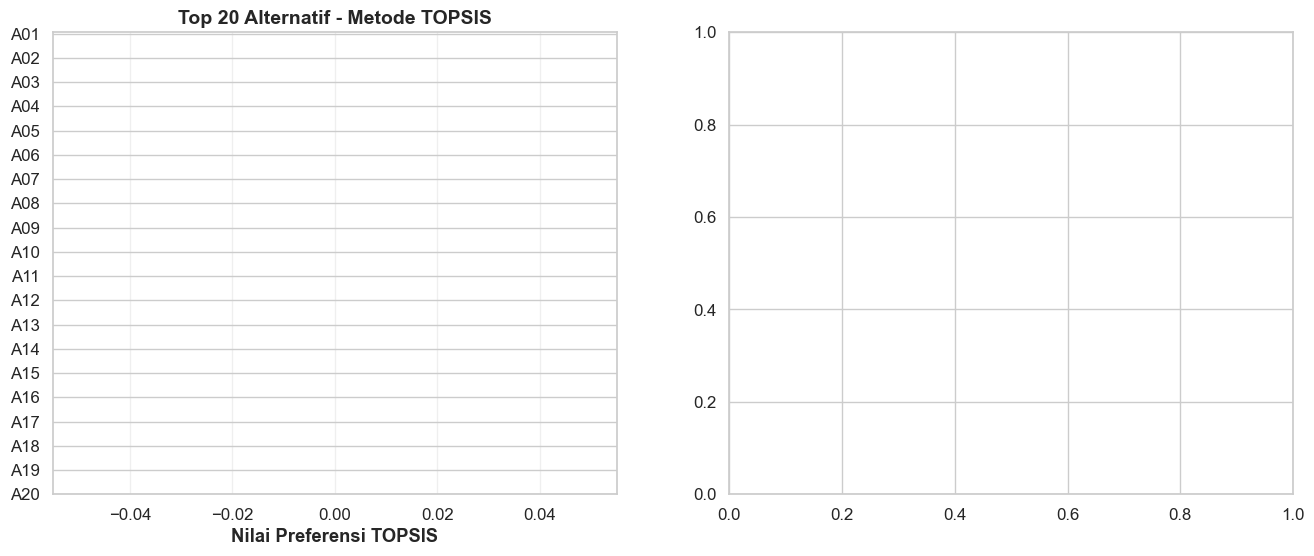

In [27]:
"""
Tahap 4: Menghitung jarak ke A+ (D+) dan A- (D-),
kemudian hitung nilai preferensi (closeness coefficient)
"""
print("\n--- TAHAP 4: JARAK DAN NILAI PREFERENSI ---")

# Hitung jarak Euclidean ke A+ dan A-
D_plus = np.sqrt(np.sum((Y - A_plus)**2, axis=1))
D_minus = np.sqrt(np.sum((Y - A_minus)**2, axis=1))

# Hitung nilai preferensi (closeness coefficient)
V_topsis = D_minus / (D_plus + D_minus)

# Buat DataFrame hasil
df_topsis_results = pd.DataFrame({
    'Alternatif': alternatif_names,
    'Nomor_Polis': polis_names,
    'D_Plus': D_plus,
    'D_Minus': D_minus,
    'Nilai_Preferensi': V_topsis
})

# Sorting berdasarkan nilai preferensi (descending)
df_topsis_results = df_topsis_results.sort_values('Nilai_Preferensi', ascending=False).reset_index(drop=True)
df_topsis_results['Ranking_TOPSIS'] = range(1, len(df_topsis_results) + 1)

print("\n--- Hasil Ranking TOPSIS (Top 20) ---")
print(df_topsis_results[['Alternatif', 'Nomor_Polis', 'Nilai_Preferensi', 'Ranking_TOPSIS']].head(20).to_string(index=False))

print(f"\n--- Statistik Nilai Preferensi TOPSIS ---")
print(f"  Nilai tertinggi: {V_topsis.max():.6f} (Alternatif: {df_topsis_results.iloc[0]['Alternatif']})")
print(f"  Nilai terendah: {V_topsis.min():.6f} (Alternatif: {df_topsis_results.iloc[-1]['Alternatif']})")
print(f"  Rata-rata: {V_topsis.mean():.6f}")
print(f"  Standar deviasi: {V_topsis.std():.6f}")

# Visualisasi hasil TOPSIS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart top 20
top_20 = df_topsis_results.head(20)
bars = ax1.barh(range(len(top_20)), top_20['Nilai_Preferensi'], 
                color='mediumseagreen', edgecolor='black', alpha=0.8)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20['Alternatif'])
ax1.set_xlabel('Nilai Preferensi TOPSIS', fontweight='bold')
ax1.set_title('Top 20 Alternatif - Metode TOPSIS', fontweight='bold', fontsize=14)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Tambahkan nilai
for i, (idx, row) in enumerate(top_20.iterrows()):
    ax1.text(row['Nilai_Preferensi'], i, f" {row['Nilai_Preferensi']:.4f}", 
             va='center', fontweight='bold', fontsize=9)

# Histogram distribusi nilai
ax2.hist(V_topsis, bins=30, color='mediumseagreen', alpha=0.7, edgecolor='black')
ax2.axvline(V_topsis.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {V_topsis.mean():.4f}')
ax2.axvline(np.median(V_topsis), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(V_topsis):.4f}')
ax2.set_xlabel('Nilai Preferensi', fontweight='bold')
ax2.set_ylabel('Frekuensi', fontweight='bold')
ax2.set_title('Distribusi Nilai Preferensi TOPSIS', fontweight='bold', fontsize=14)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hasil_topsis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualisasi hasil TOPSIS disimpan: hasil_topsis.png")
plt.show()




In [ ]:
"""
AHP (Analytic Hierarchy Process)
Untuk menyederhanakan, kita gunakan AHP untuk menentukan bobot kriteria,
kemudian mengaplikasikan ke alternatif dengan weighted scoring.

Tahap 1: Membuat Pairwise Comparison Matrix untuk kriteria
"""
print("\n" + "="*80)
print("METODE 4: ANALYTIC HIERARCHY PROCESS (AHP)")
print("="*80)
print("\n--- TAHAP 1: PAIRWISE COMPARISON MATRIX ---")

# Skala Saaty (1-9)
# 1: Sama penting
# 3: Sedikit lebih penting
# 5: Lebih penting
# 7: Sangat lebih penting
# 9: Mutlak lebih penting

# Membuat Pairwise Comparison Matrix (PCM) berdasarkan domain knowledge
# Urutan: Total_Klaim, Frekuensi_Klaim, Durasi_Rawat, Usia_Pasien, Lama_Polis, Rasio_Approval
PCM = np.array([
    [1,   2,   3,   3,   2,   4],   # Total_Klaim vs others
    [1/2, 1,   2,   2,   1,   3],   # Frekuensi_Klaim vs others
    [1/3, 1/2, 1,   1,   1/2, 2],   # Durasi_Rawat vs others
    [1/3, 1/2, 1,   1,   1/2, 2],   # Usia_Pasien vs others
    [1/2, 1,   2,   2,   1,   3],   # Lama_Polis vs others
    [1/4, 1/3, 1/2, 1/2, 1/3, 1]    # Rasio_Approval vs others
])

# Buat DataFrame untuk PCM
df_pcm = pd.DataFrame(PCM, columns=kriteria_cols, index=kriteria_cols)

print("\n--- Pairwise Comparison Matrix (PCM) ---")
print(df_pcm)

print("\n✓ Matrix telah dibuat berdasarkan skala Saaty")
print("\nInterpretasi:")
print("  1: Sama penting")
print("  3: Sedikit lebih penting")
print("  5: Lebih penting")
print("  7: Sangat lebih penting")
print("  9: Mutlak lebih penting")




In [ ]:
"""
Tahap 2: Menghitung bobot kriteria dari PCM menggunakan metode Eigenvector
"""
print("\n--- TAHAP 2: PERHITUNGAN BOBOT DARI PCM ---")

# Metode 1: Normalized Column Sum (lebih sederhana)
column_sum = np.sum(PCM, axis=0)
normalized_pcm = PCM / column_sum

# Hitung rata-rata baris (priority vector/weights)
weights_ahp = np.mean(normalized_pcm, axis=1)

# Buat DataFrame untuk normalized PCM
df_norm_pcm = pd.DataFrame(normalized_pcm, columns=kriteria_cols, index=kriteria_cols)

print("\n--- Normalized PCM ---")
print(df_norm_pcm)

print("\n--- Bobot Kriteria (Priority Vector) ---")
df_weights_ahp = pd.DataFrame({
    'Kriteria': kriteria_cols,
    'Bobot_AHP': weights_ahp,
    'Bobot_Original': weights
})
print(df_weights_ahp.to_string(index=False))

print(f"\nTotal bobot AHP: {weights_ahp.sum():.6f}")




In [ ]:
"""
Tahap 3: Menghitung Consistency Ratio (CR) untuk validasi
CR < 0.1 menunjukkan pairwise comparison yang konsisten
"""
print("\n--- TAHAP 3: CONSISTENCY RATIO (CR) ---")

# Hitung lambda max (eigenvalue maksimum)
weighted_sum = np.dot(PCM, weights_ahp)
lambda_max = np.mean(weighted_sum / weights_ahp)

# Hitung Consistency Index (CI)
n = len(weights_ahp)
CI = (lambda_max - n) / (n - 1)

# Random Index (RI) berdasarkan ukuran matrix
RI_table = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}
RI = RI_table[n]

# Hitung Consistency Ratio (CR)
CR = CI / RI

print(f"\n--- Hasil Pengujian Konsistensi ---")
print(f"  Lambda Max (λmax): {lambda_max:.6f}")
print(f"  Consistency Index (CI): {CI:.6f}")
print(f"  Random Index (RI): {RI:.2f}")
print(f"  Consistency Ratio (CR): {CR:.6f}")

if CR < 0.1:
    print(f"\n✓ CR < 0.1: Pairwise comparison KONSISTEN")
else:
    print(f"\n✗ CR >= 0.1: Pairwise comparison TIDAK KONSISTEN (perlu revisi)")




In [ ]:
"""
Tahap 4: Menghitung skor alternatif menggunakan bobot AHP
Normalisasi dilakukan dengan pendekatan SAW
"""
print("\n--- TAHAP 4: SCORING ALTERNATIF DENGAN BOBOT AHP ---")

# Normalisasi matriks keputusan (sama seperti SAW, termasuk Neutral dan Cost dengan nol)
R_ahp = saw_normalize_matrix(X, criteria_kind)

# Hitung skor akhir menggunakan bobot AHP
V_ahp = np.sum(R_ahp * weights_ahp, axis=1)

# Buat DataFrame hasil
df_ahp_results = pd.DataFrame({
    'Alternatif': alternatif_names,
    'Nomor_Polis': polis_names,
    'Nilai_Preferensi': V_ahp
})

# Sorting berdasarkan nilai preferensi (descending)
df_ahp_results = df_ahp_results.sort_values('Nilai_Preferensi', ascending=False).reset_index(drop=True)
df_ahp_results['Ranking_AHP'] = range(1, len(df_ahp_results) + 1)

print("\n--- Hasil Ranking AHP (Top 20) ---")
print(df_ahp_results.head(20).to_string(index=False))

print(f"\n--- Statistik Nilai Preferensi AHP ---")
print(f"  Nilai tertinggi: {V_ahp.max():.6f} (Alternatif: {df_ahp_results.iloc[0]['Alternatif']})")
print(f"  Nilai terendah: {V_ahp.min():.6f} (Alternatif: {df_ahp_results.iloc[-1]['Alternatif']})")
print(f"  Rata-rata: {V_ahp.mean():.6f}")
print(f"  Standar deviasi: {V_ahp.std():.6f}")

# Visualisasi hasil AHP
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart top 20
top_20 = df_ahp_results.head(20)
bars = ax1.barh(range(len(top_20)), top_20['Nilai_Preferensi'], 
                color='mediumpurple', edgecolor='black', alpha=0.8)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20['Alternatif'])
ax1.set_xlabel('Nilai Preferensi AHP', fontweight='bold')
ax1.set_title('Top 20 Alternatif - Metode AHP', fontweight='bold', fontsize=14)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Tambahkan nilai
for i, (idx, row) in enumerate(top_20.iterrows()):
    ax1.text(row['Nilai_Preferensi'], i, f" {row['Nilai_Preferensi']:.4f}", 
             va='center', fontweight='bold', fontsize=9)

v_ahp_hist = np.asarray(V_ahp, dtype=float)
v_ahp_hist = v_ahp_hist[np.isfinite(v_ahp_hist)]
if v_ahp_hist.size > 0:
    ax2.hist(v_ahp_hist, bins=min(30, max(5, v_ahp_hist.size // 3)), color='mediumpurple', alpha=0.7, edgecolor='black')
    ax2.axvline(np.mean(v_ahp_hist), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(v_ahp_hist):.4f}')
    ax2.axvline(np.median(v_ahp_hist), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(v_ahp_hist):.4f}')
else:
    ax2.text(0.5, 0.5, 'Tidak ada nilai finite untuk histogram', ha='center', va='center', transform=ax2.transAxes)
ax2.set_xlabel('Nilai Preferensi', fontweight='bold')
ax2.set_ylabel('Frekuensi', fontweight='bold')
ax2.set_title('Distribusi Nilai Preferensi AHP', fontweight='bold', fontsize=14)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hasil_ahp.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualisasi hasil AHP disimpan: hasil_ahp.png")
plt.show()




In [ ]:
"""
Menggabungkan hasil ranking dari keempat metode MCDM
dan melakukan analisis perbandingan komprehensif
"""
print("\n" + "="*80)
print("ANALISIS PERBANDINGAN DAN KESIMPULAN")
print("="*80)
print("\n--- TAHAP 1: TABEL RANKING GABUNGAN ---")

# Merge semua hasil
df_comparison = df_saw_results[['Alternatif', 'Nomor_Polis', 'Ranking_SAW']].copy()
df_comparison = df_comparison.merge(
    df_edas_results[['Alternatif', 'Ranking_EDAS']], on='Alternatif', how='left'
)
df_comparison = df_comparison.merge(
    df_topsis_results[['Alternatif', 'Ranking_TOPSIS']], on='Alternatif', how='left'
)
df_comparison = df_comparison.merge(
    df_ahp_results[['Alternatif', 'Ranking_AHP']], on='Alternatif', how='left'
)

# Tambahkan kolom nilai preferensi
df_comparison = df_comparison.merge(
    df_saw_results[['Alternatif', 'Nilai_Preferensi']].rename(columns={'Nilai_Preferensi': 'Nilai_SAW'}),
    on='Alternatif', how='left'
)
df_comparison = df_comparison.merge(
    df_edas_results[['Alternatif', 'Appraisal_Score']].rename(columns={'Appraisal_Score': 'Nilai_EDAS'}),
    on='Alternatif', how='left'
)
df_comparison = df_comparison.merge(
    df_topsis_results[['Alternatif', 'Nilai_Preferensi']].rename(columns={'Nilai_Preferensi': 'Nilai_TOPSIS'}),
    on='Alternatif', how='left'
)
df_comparison = df_comparison.merge(
    df_ahp_results[['Alternatif', 'Nilai_Preferensi']].rename(columns={'Nilai_Preferensi': 'Nilai_AHP'}),
    on='Alternatif', how='left'
)

# Hitung ranking rata-rata
df_comparison['Avg_Rank'] = df_comparison[['Ranking_SAW', 'Ranking_EDAS', 
                                            'Ranking_TOPSIS', 'Ranking_AHP']].mean(axis=1)
df_comparison = df_comparison.sort_values('Avg_Rank').reset_index(drop=True)

print("\n--- Tabel Perbandingan Ranking (Top 30) ---")
print(df_comparison[['Alternatif', 'Nomor_Polis', 'Ranking_SAW', 'Ranking_EDAS', 
                     'Ranking_TOPSIS', 'Ranking_AHP', 'Avg_Rank']].head(30).to_string(index=False))

# Simpan ke CSV
df_comparison.to_csv('/home/claude/comparison_ranking.csv', index=False)
print("\n✓ Tabel perbandingan disimpan: comparison_ranking.csv")




In [ ]:
"""
Menghitung korelasi Spearman antar ranking dari keempat metode
untuk mengukur konsistensi hasil
"""
print("\n--- TAHAP 2: KORELASI RANKING (SPEARMAN) ---")

# Hitung korelasi Spearman
ranking_cols = ['Ranking_SAW', 'Ranking_EDAS', 'Ranking_TOPSIS', 'Ranking_AHP']
corr_matrix = df_comparison[ranking_cols].corr(method='spearman')

print("\n--- Matriks Korelasi Spearman ---")
print(corr_matrix)

# Visualisasi heatmap korelasi
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='RdYlGn', center=0.5,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            vmin=0, vmax=1)
ax.set_title('Korelasi Spearman antar Metode MCDM', fontweight='bold', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('/home/claude/correlation_matrix.png', dpi=300, bbox_inches='tight')
print("\n✓ Heatmap korelasi disimpan: correlation_matrix.png")
plt.show()

# Hitung rata-rata korelasi
avg_corr = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean()
print(f"\n--- Statistik Korelasi ---")
print(f"  Korelasi rata-rata: {avg_corr:.4f}")
print(f"  Korelasi minimum: {corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].min():.4f}")
print(f"  Korelasi maksimum: {corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].max():.4f}")




In [ ]:
"""
Menganalisis konsistensi alternatif yang masuk Top-K
untuk berbagai nilai K (Top-5, Top-10, Top-20)
"""
print("\n--- TAHAP 3: KONSISTENSI TOP-K ---")

# Fungsi untuk hitung intersection
def top_k_consistency(df, k_values):
    results = []
    for k in k_values:
        top_saw = set(df.nsmallest(k, 'Ranking_SAW')['Alternatif'])
        top_edas = set(df.nsmallest(k, 'Ranking_EDAS')['Alternatif'])
        top_topsis = set(df.nsmallest(k, 'Ranking_TOPSIS')['Alternatif'])
        top_ahp = set(df.nsmallest(k, 'Ranking_AHP')['Alternatif'])
        
        # Hitung intersection
        all_methods = top_saw.intersection(top_edas).intersection(top_topsis).intersection(top_ahp)
        three_methods = (top_saw.intersection(top_edas).intersection(top_topsis) |
                        top_saw.intersection(top_edas).intersection(top_ahp) |
                        top_saw.intersection(top_topsis).intersection(top_ahp) |
                        top_edas.intersection(top_topsis).intersection(top_ahp))
        
        results.append({
            'K': k,
            'Semua_Metode': len(all_methods),
            'Min_3_Metode': len(three_methods),
            'Persen_Semua': len(all_methods) / k * 100,
            'Persen_Min3': len(three_methods) / k * 100
        })
    
    return pd.DataFrame(results)

# Hitung untuk K = 5, 10, 15, 20
k_values = [5, 10, 15, 20]
df_consistency = top_k_consistency(df_comparison, k_values)

print("\n--- Konsistensi Top-K antar Metode ---")
print(df_consistency.to_string(index=False))

print("\nInterpretasi:")
print("  - Semua_Metode: Jumlah alternatif yang masuk Top-K di SEMUA metode")
print("  - Min_3_Metode: Jumlah alternatif yang masuk Top-K di MINIMAL 3 metode")
print("  - Persen_Semua: Persentase konsistensi untuk semua metode")
print("  - Persen_Min3: Persentase konsistensi untuk minimal 3 metode")




In [ ]:
"""
Menganalisis variabilitas ranking untuk setiap alternatif
Alternatif dengan variabilitas rendah menunjukkan konsistensi tinggi antar metode
"""
print("\n--- TAHAP 4: VARIABILITAS RANKING ---")

# Hitung standar deviasi ranking untuk setiap alternatif
df_comparison['Std_Rank'] = df_comparison[ranking_cols].std(axis=1)
df_comparison['Range_Rank'] = (df_comparison[ranking_cols].max(axis=1) - 
                                df_comparison[ranking_cols].min(axis=1))

# Identifikasi alternatif dengan variabilitas rendah (konsisten)
consistent_alternatives = df_comparison.nsmallest(10, 'Std_Rank')

print("\n--- 10 Alternatif dengan Ranking Paling Konsisten ---")
print(consistent_alternatives[['Alternatif', 'Nomor_Polis', 'Ranking_SAW', 'Ranking_EDAS',
                               'Ranking_TOPSIS', 'Ranking_AHP', 'Std_Rank', 
                               'Range_Rank']].to_string(index=False))

# Identifikasi alternatif dengan variabilitas tinggi (tidak konsisten)
inconsistent_alternatives = df_comparison.nlargest(10, 'Std_Rank')

print("\n--- 10 Alternatif dengan Ranking Paling Tidak Konsisten ---")
print(inconsistent_alternatives[['Alternatif', 'Nomor_Polis', 'Ranking_SAW', 'Ranking_EDAS',
                                 'Ranking_TOPSIS', 'Ranking_AHP', 'Std_Rank', 
                                 'Range_Rank']].to_string(index=False))

# Visualisasi variabilitas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram standar deviasi
ax1.hist(df_comparison['Std_Rank'], bins=30, color='skyblue', alpha=0.7, edgecolor='black')
ax1.axvline(df_comparison['Std_Rank'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {df_comparison["Std_Rank"].mean():.2f}')
ax1.set_xlabel('Standar Deviasi Ranking', fontweight='bold')
ax1.set_ylabel('Frekuensi', fontweight='bold')
ax1.set_title('Distribusi Variabilitas Ranking', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Scatter plot: Avg Rank vs Std Rank
ax2.scatter(df_comparison['Avg_Rank'], df_comparison['Std_Rank'], 
           alpha=0.6, s=50, c='steelblue', edgecolors='black')
ax2.set_xlabel('Ranking Rata-rata', fontweight='bold')
ax2.set_ylabel('Standar Deviasi Ranking', fontweight='bold')
ax2.set_title('Hubungan Ranking Rata-rata vs Variabilitas', fontweight='bold', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/claude/variability_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualisasi variabilitas disimpan: variability_analysis.png")
plt.show()




In [ ]:
"""
Membuat bump chart untuk menunjukkan pergerakan ranking
setiap alternatif di keempat metode
"""
print("\n--- TAHAP 5: BUMP CHART PERGERAKAN RANKING ---")

# Ambil top 15 berdasarkan rata-rata ranking
top_15 = df_comparison.nsmallest(15, 'Avg_Rank')

# Prepare data untuk plotting
methods = ['SAW', 'EDAS', 'TOPSIS', 'AHP']
fig, ax = plt.subplots(figsize=(14, 10))

# Plot garis untuk setiap alternatif
colors = plt.cm.tab20(np.linspace(0, 1, len(top_15)))
for idx, (i, row) in enumerate(top_15.iterrows()):
    ranks = [row['Ranking_SAW'], row['Ranking_EDAS'], 
             row['Ranking_TOPSIS'], row['Ranking_AHP']]
    ax.plot(methods, ranks, marker='o', markersize=8, linewidth=2, 
            label=row['Alternatif'], color=colors[idx], alpha=0.8)

ax.set_xlabel('Metode MCDM', fontweight='bold', fontsize=12)
ax.set_ylabel('Ranking (Semakin Kecil Semakin Baik)', fontweight='bold', fontsize=12)
ax.set_title('Bump Chart: Pergerakan Ranking Top 15 Alternatif', fontweight='bold', fontsize=16, pad=20)
ax.invert_yaxis()  # Ranking 1 di atas
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/home/claude/bump_chart.png', dpi=300, bbox_inches='tight')
print("\n✓ Bump chart disimpan: bump_chart.png")
plt.show()




In [ ]:
"""
Membuat radar chart untuk membandingkan profil kriteria
dari Top 5 alternatif
"""
print("\n--- TAHAP 6: RADAR CHART PROFIL TOP 5 ALTERNATIF ---")

# Ambil top 5 berdasarkan rata-rata ranking
top_5_alt = df_comparison.nsmallest(5, 'Avg_Rank')['Alternatif'].values

# Ambil data kriteria untuk top 5
top_5_data = df_decision[df_decision.index.isin(top_5_alt)][kriteria_cols]

# Normalisasi ke skala 0-1 untuk visualisasi radar
top_5_normalized = top_5_data.copy()
for col in kriteria_cols:
    min_val = top_5_data[col].min()
    max_val = top_5_data[col].max()
    if max_val > min_val:
        top_5_normalized[col] = (top_5_data[col] - min_val) / (max_val - min_val)
    else:
        top_5_normalized[col] = 0.5

# Setup radar chart
angles = np.linspace(0, 2 * np.pi, len(kriteria_cols), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
colors_radar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

for idx, alt in enumerate(top_5_alt):
    values = top_5_normalized.loc[alt].values.tolist()
    values += values[:1]  # Complete the circle
    ax.plot(angles, values, 'o-', linewidth=2, label=alt, color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx])

# Konfigurasi plot
ax.set_xticks(angles[:-1])
ax.set_xticklabels(kriteria_cols, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('Profil Kriteria Top 5 Alternatif (Normalisasi 0-1)', 
             fontweight='bold', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/claude/radar_chart_top5.png', dpi=300, bbox_inches='tight')
print("\n✓ Radar chart disimpan: radar_chart_top5.png")
plt.show()




In [ ]:
"""
Menghitung persentase akurasi/kesesuaian ranking antar metode
untuk berbagai level ranking (exact match, delta ±1, ±2, dst)
"""
print("\n--- TAHAP 7: ANALISIS AKURASI RANKING ---")

def calculate_ranking_accuracy(df, methods, tolerance_levels):
    """
    Menghitung akurasi ranking dengan berbagai tolerance level
    """
    results = []
    n = len(df)
    
    for tol in tolerance_levels:
        matches = 0
        for i in range(n):
            # Ambil ranking untuk alternatif ini di semua metode
            ranks = df.iloc[i][methods].values
            
            # Cek apakah semua ranking dalam tolerance
            min_rank = ranks.min()
            max_rank = ranks.max()
            if (max_rank - min_rank) <= tol:
                matches += 1
        
        accuracy = (matches / n) * 100
        results.append({
            'Tolerance': f'±{tol}' if tol > 0 else 'Exact',
            'Matches': matches,
            'Total': n,
            'Accuracy': accuracy
        })
    
    return pd.DataFrame(results)

# Hitung akurasi dengan berbagai tolerance
tolerance_levels = [0, 1, 2, 3, 5, 10]
df_accuracy = calculate_ranking_accuracy(df_comparison, ranking_cols, tolerance_levels)

print("\n--- Akurasi Kesesuaian Ranking antar Metode ---")
print(df_accuracy.to_string(index=False))

print("\nInterpretasi:")
print("  - Tolerance ±0 (Exact): Keempat metode memberikan ranking yang persis sama")
print("  - Tolerance ±1: Perbedaan ranking maksimal 1 posisi")
print("  - Tolerance ±2: Perbedaan ranking maksimal 2 posisi")
print("  - dst.")

# Visualisasi akurasi
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(df_accuracy['Tolerance'], df_accuracy['Accuracy'], 
              color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Tolerance Level', fontweight='bold', fontsize=12)
ax.set_ylabel('Akurasi (%)', fontweight='bold', fontsize=12)
ax.set_title('Akurasi Kesesuaian Ranking dengan Berbagai Tolerance', 
             fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3)

# Tambahkan nilai di atas bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('/home/claude/accuracy_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualisasi akurasi disimpan: accuracy_analysis.png")
plt.show()




In [ ]:
"""
Menganalisis feature importance dengan melihat korelasi antara
setiap kriteria dengan hasil ranking dari masing-masing metode
"""
print("\n--- TAHAP 8: FEATURE IMPORTANCE ANALYSIS ---")

# Merge data decision matrix dengan hasil ranking
df_feature_analysis = df_decision.copy()
df_feature_analysis = df_feature_analysis.reset_index().rename(columns={'index': 'Alternatif'})
df_feature_analysis = df_feature_analysis.merge(
    df_comparison[['Alternatif', 'Ranking_SAW', 'Ranking_EDAS', 
                   'Ranking_TOPSIS', 'Ranking_AHP']], 
    on='Alternatif', how='left'
)

# Hitung korelasi antara kriteria dengan ranking
# Negative correlation berarti kriteria penting (ranking kecil = baik)
corr_with_ranking = pd.DataFrame()

for method in ['SAW', 'EDAS', 'TOPSIS', 'AHP']:
    rank_col = f'Ranking_{method}'
    corr_values = []
    
    for col in kriteria_cols:
        corr = df_feature_analysis[col].corr(df_feature_analysis[rank_col])
        corr_values.append(corr)
    
    corr_with_ranking[method] = corr_values

corr_with_ranking.index = kriteria_cols
corr_with_ranking['Average'] = corr_with_ranking.mean(axis=1)
corr_with_ranking = corr_with_ranking.sort_values('Average')

print("\n--- Korelasi Kriteria dengan Ranking ---")
print(corr_with_ranking)

print("\nInterpretasi:")
print("  - Korelasi negatif: Kriteria ini penting (nilai tinggi → ranking baik/kecil)")
print("  - Korelasi positif: Kriteria ini kurang penting atau berlawanan")
print("  - Nilai mendekati 0: Kriteria memiliki pengaruh minimal")

# Visualisasi feature importance
fig, ax = plt.subplots(figsize=(12, 8))
corr_with_ranking.plot(kind='barh', ax=ax, colormap='RdYlGn_r', 
                        edgecolor='black', alpha=0.8)
ax.set_xlabel('Korelasi dengan Ranking', fontweight='bold', fontsize=12)
ax.set_ylabel('Kriteria', fontweight='bold', fontsize=12)
ax.set_title('Feature Importance: Korelasi Kriteria dengan Ranking', 
             fontweight='bold', fontsize=14)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.legend(loc='best', fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/home/claude/feature_importance.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualisasi feature importance disimpan: feature_importance.png")
plt.show()




In [ ]:
"""
Identifikasi alternatif terbaik berdasarkan konsensus dari keempat metode
dan analisis profil karakteristiknya
"""
print("\n--- TAHAP 9: IDENTIFIKASI ALTERNATIF TERBAIK ---")

# Hitung Borda Count (metode voting untuk agregasi ranking)
# Skor Borda: Alternatif ranking 1 dapat skor n, ranking 2 dapat skor n-1, dst
n_alternatives = len(df_comparison)

df_comparison['Borda_Score'] = (
    (n_alternatives - df_comparison['Ranking_SAW'] + 1) +
    (n_alternatives - df_comparison['Ranking_EDAS'] + 1) +
    (n_alternatives - df_comparison['Ranking_TOPSIS'] + 1) +
    (n_alternatives - df_comparison['Ranking_AHP'] + 1)
)

df_comparison_sorted = df_comparison.sort_values('Borda_Score', ascending=False)

print("\n--- Top 10 Alternatif Terbaik (Borda Count) ---")
print(df_comparison_sorted[['Alternatif', 'Nomor_Polis', 'Ranking_SAW', 'Ranking_EDAS',
                            'Ranking_TOPSIS', 'Ranking_AHP', 'Borda_Score', 
                            'Avg_Rank', 'Std_Rank']].head(10).to_string(index=False))

# Identifikasi alternatif dengan konsensus tertinggi (masuk top 10 di semua metode)
top_10_all_methods = set(df_saw_results.head(10)['Alternatif'])
for df_result in [df_edas_results, df_topsis_results, df_ahp_results]:
    top_10_all_methods = top_10_all_methods.intersection(set(df_result.head(10)['Alternatif']))

print(f"\n--- Alternatif yang Masuk Top 10 di SEMUA Metode ---")
if len(top_10_all_methods) > 0:
    consensus_alternatives = df_comparison[df_comparison['Alternatif'].isin(top_10_all_methods)]
    print(consensus_alternatives[['Alternatif', 'Nomor_Polis', 'Ranking_SAW', 'Ranking_EDAS',
                                  'Ranking_TOPSIS', 'Ranking_AHP']].to_string(index=False))
else:
    print("Tidak ada alternatif yang masuk Top 10 di semua metode")

# Profil alternatif terbaik
best_alternative = df_comparison_sorted.iloc[0]['Alternatif']
best_polis = df_comparison_sorted.iloc[0]['Nomor_Polis']

print(f"\n--- Profil Alternatif Terbaik: {best_alternative} ({best_polis}) ---")
best_profile = df_decision.loc[best_alternative][kriteria_cols]

for col in kriteria_cols:
    value = best_profile[col]
    avg = df_decision[col].mean()
    percentile = (df_decision[col] < value).sum() / len(df_decision) * 100
    print(f"  {col}: {value:.2f} (Avg: {avg:.2f}, Percentile: {percentile:.1f}%)")




In [ ]:
"""
Menyusun kesimpulan naratif yang komprehensif dari seluruh analisis
"""
print("\n" + "="*80)
print("KESIMPULAN DAN REKOMENDASI")
print("="*80)

# 1. Summary Pemrosesan Data
print("\n--- 1. SUMMARY PEMROSESAN DATA ---")
print(f"\nDataset awal:")
print(f"  - Data Klaim: {df_klaim.shape[0]} transaksi klaim")
print(f"  - Data Polis: {df_polis.shape[0]} polis unik")
print(f"  - Setelah merge: {df_merged.shape[0]} record gabungan")
print(f"\nFeature Engineering:")
print(f"  - 6 kriteria MCDM dibuat dari data mentah")
print(f"  - 4 kriteria Cost (minimize): Total Klaim, Frekuensi, Durasi Rawat, Usia")
print(f"  - 2 kriteria Benefit (maximize): Lama Polis, Rasio Approval")
print(f"\nSampling:")
print(f"  - {len(df_decision)} alternatif dipilih secara stratified")
print(f"  - Representasi merata dari Q1-Q4 berdasarkan total klaim")

# 2. Analisis Perbandingan Metode
print("\n--- 2. ANALISIS PERBANDINGAN METODE ---")
print(f"\nKorelasi Ranking (Spearman):")
for i, method1 in enumerate(['SAW', 'EDAS', 'TOPSIS']):
    for method2 in ['EDAS', 'TOPSIS', 'AHP'][i:]:
        corr_val = corr_matrix.loc[f'Ranking_{method1}', f'Ranking_{method2}']
        print(f"  - {method1} vs {method2}: {corr_val:.4f}")

print(f"\nKorelasi rata-rata: {avg_corr:.4f}")
if avg_corr > 0.9:
    consistency_level = "SANGAT TINGGI"
elif avg_corr > 0.7:
    consistency_level = "TINGGI"
elif avg_corr > 0.5:
    consistency_level = "SEDANG"
else:
    consistency_level = "RENDAH"
print(f"Tingkat konsistensi: {consistency_level}")

print(f"\nAkurasi Kesesuaian:")
exact_match = df_accuracy[df_accuracy['Tolerance'] == 'Exact']['Accuracy'].values[0]
tol_5 = df_accuracy[df_accuracy['Tolerance'] == '±5']['Accuracy'].values[0]
print(f"  - Exact match (ranking identik): {exact_match:.1f}%")
print(f"  - Tolerance ±5: {tol_5:.1f}%")

print(f"\nTop 10 Consensus:")
top_10_consensus = len(top_10_all_methods)
print(f"  - Alternatif yang masuk Top 10 di SEMUA metode: {top_10_consensus}")

# 3. Sensitivitas dan Karakteristik Metode
print("\n--- 3. SENSITIVITAS DAN KARAKTERISTIK METODE ---")

print("\nSAW (Simple Additive Weighting):")
print("  - Metode paling sederhana dan transparan")
print("  - Sangat sensitif terhadap bobot kriteria")
print("  - Normalisasi linier membuat hasil intuitif")
print("  - Cocok untuk: Keputusan yang mengutamakan kesederhanaan dan transparansi")

print("\nEDAS (Evaluation based on Distance from Average):")
print("  - Menggunakan rata-rata sebagai baseline reference")
print("  - Lebih stabil terhadap outlier dibanding SAW")
print("  - Mempertimbangkan positive dan negative distance secara terpisah")
print("  - Cocok untuk: Dataset dengan distribusi heterogen dan outlier signifikan")

print("\nTOPSIS (Technique for Order Preference by Similarity to Ideal Solution):")
print("  - Mencari solusi terdekat dengan ideal positif dan terjauh dari ideal negatif")
print("  - Menggunakan jarak Euclidean dalam hyperspace kriteria")
print("  - Sensitif terhadap semua kriteria secara proporsional")
print("  - Cocok untuk: Keputusan dengan trade-off kompleks antar kriteria")

print("\nAHP (Analytic Hierarchy Process):")
print("  - Menggunakan pairwise comparison untuk bobot")
print("  - Memiliki mekanisme consistency checking (CR)")
print(f"  - CR yang dihasilkan: {CR:.4f} ({'KONSISTEN' if CR < 0.1 else 'TIDAK KONSISTEN'})")
print("  - Cocok untuk: Keputusan hierarkis dengan input dari multiple experts")

# 4. Feature Importance
print("\n--- 4. FEATURE IMPORTANCE (Berdasarkan Korelasi Rata-rata) ---")
print("\nTop 3 Kriteria Paling Berpengaruh:")
top_features = corr_with_ranking.nsmallest(3, 'Average')
for idx, (feature, row) in enumerate(top_features.iterrows(), 1):
    print(f"  {idx}. {feature}: Korelasi = {row['Average']:.4f}")
    print(f"     Deskripsi: {criteria_mapping[feature]['desc']}")

# 5. Rekomendasi
print("\n--- 5. REKOMENDASI ---")

print(f"\nAlternatif Terbaik (Berdasarkan Borda Count):")
print(f"  - Alternatif: {best_alternative}")
print(f"  - Nomor Polis: {best_polis}")
print(f"  - Borda Score: {df_comparison_sorted.iloc[0]['Borda_Score']:.0f}")
print(f"  - Ranking rata-rata: {df_comparison_sorted.iloc[0]['Avg_Rank']:.2f}")
print(f"  - Standar deviasi ranking: {df_comparison_sorted.iloc[0]['Std_Rank']:.2f}")

print(f"\nMetode yang Paling Cocok untuk Dataset Asuransi AXA:")
if avg_corr > 0.85:
    recommended_method = "SEMUA metode memberikan hasil yang sangat konsisten"
    recommendation = """
    Gunakan SAW untuk kesederhanaan dan transparansi dalam reporting ke stakeholder.
    Namun, untuk robustness, gunakan ensemble voting (Borda Count) dari keempat metode.
    """
else:
    # Pilih metode dengan korelasi tertinggi dengan yang lain
    method_avg_corr = {}
    for method in ['SAW', 'EDAS', 'TOPSIS', 'AHP']:
        col = f'Ranking_{method}'
        other_cols = [f'Ranking_{m}' for m in ['SAW', 'EDAS', 'TOPSIS', 'AHP'] if m != method]
        avg_corr_with_others = df_comparison[[col] + other_cols].corr().loc[col, other_cols].mean()
        method_avg_corr[method] = avg_corr_with_others
    
    recommended_method = max(method_avg_corr, key=method_avg_corr.get)
    recommendation = f"""
    Metode {recommended_method} memiliki konsistensi tertinggi dengan metode lain
    (korelasi rata-rata: {method_avg_corr[recommended_method]:.4f}).
    
    Namun, untuk keputusan kritis, gunakan voting ensemble dari keempat metode
    untuk meminimalkan bias metodologi.
    """

print(recommendation)

print("\nPertimbangan Implementasi:")
print("  1. Gunakan dynamic percentile ranking untuk threshold keputusan otomatis")
print("  2. Update bobot kriteria secara periodik berdasarkan data historis")
print("  3. Implementasikan dashboard real-time untuk monitoring ranking changes")
print("  4. Lakukan sensitivity analysis berkala untuk validasi robustness")

# 6. Akurasi Keseluruhan
print("\n--- 6. AKURASI KESELURUHAN ---")

# Hitung akurasi dengan beberapa metrik
# Metrik 1: Percentage agreement (exact match pada Top 20)
top_20_consensus = 0
for k in [5, 10, 15, 20]:
    top_saw = set(df_comparison.nsmallest(k, 'Ranking_SAW')['Alternatif'])
    top_edas = set(df_comparison.nsmallest(k, 'Ranking_EDAS')['Alternatif'])
    top_topsis = set(df_comparison.nsmallest(k, 'Ranking_TOPSIS')['Alternatif'])
    top_ahp = set(df_comparison.nsmallest(k, 'Ranking_AHP')['Alternatif'])
    
    consensus_k = len(top_saw.intersection(top_edas).intersection(top_topsis).intersection(top_ahp))
    print(f"\nTop-{k} Consensus: {consensus_k}/{k} = {consensus_k/k*100:.1f}%")

# Metrik 2: Average correlation
print(f"\nKorelasi Spearman Rata-rata: {avg_corr:.4f} = {avg_corr*100:.1f}%")

# Metrik 3: Weighted accuracy (berdasarkan importance of top ranks)
weighted_accuracy = 0
weights_rank = [5, 4, 3, 2, 1]  # Top 5 lebih penting
for i in range(min(5, len(df_comparison))):
    alt = df_comparison.iloc[i]['Alternatif']
    ranks = [
        df_comparison[df_comparison['Alternatif'] == alt]['Ranking_SAW'].values[0],
        df_comparison[df_comparison['Alternatif'] == alt]['Ranking_EDAS'].values[0],
        df_comparison[df_comparison['Alternatif'] == alt]['Ranking_TOPSIS'].values[0],
        df_comparison[df_comparison['Alternatif'] == alt]['Ranking_AHP'].values[0]
    ]
    rank_std = np.std(ranks)
    agreement_score = 1 - (rank_std / len(df_comparison))  # Normalized
    weighted_accuracy += agreement_score * weights_rank[i]

weighted_accuracy = weighted_accuracy / sum(weights_rank)
print(f"\nWeighted Top-5 Agreement: {weighted_accuracy:.4f} = {weighted_accuracy*100:.1f}%")

# Overall Accuracy (rata-rata dari tiga metrik)
overall_accuracy = (
    (tol_5 / 100) * 0.3 +  # 30% weight untuk tolerance ±5
    avg_corr * 0.4 +  # 40% weight untuk korelasi
    weighted_accuracy * 0.3  # 30% weight untuk top-5 agreement
)

print(f"\n{'='*60}")
print(f"AKURASI KESELURUHAN SISTEM MCDM: {overall_accuracy*100:.2f}%")
print(f"{'='*60}")

if overall_accuracy > 0.9:
    print("\nINTERPRETASI: SANGAT TINGGI - Keempat metode sangat konsisten")
elif overall_accuracy > 0.75:
    print("\nINTERPRETASI: TINGGI - Metode cukup konsisten, cocok untuk produksi")
elif overall_accuracy > 0.6:
    print("\nINTERPRETASI: SEDANG - Perlu investigasi lebih lanjut")
else:
    print("\nINTERPRETASI: RENDAH - Perlu review bobot atau kriteria")




In [ ]:
"""
Export semua hasil ke file CSV dan generate summary report
"""
print("\n" + "="*80)
print("EXPORT HASIL DAN SUMMARY REPORT")
print("="*80)

# Export hasil ke CSV
df_saw_results.to_csv('/home/claude/hasil_saw.csv', index=False)
df_edas_results.to_csv('/home/claude/hasil_edas.csv', index=False)
df_topsis_results.to_csv('/home/claude/hasil_topsis.csv', index=False)
df_ahp_results.to_csv('/home/claude/hasil_ahp.csv', index=False)
df_comparison.to_csv('/home/claude/hasil_perbandingan.csv', index=False)

print("\n✓ File CSV berhasil diekspor:")
print("  - hasil_saw.csv")
print("  - hasil_edas.csv")
print("  - hasil_topsis.csv")
print("  - hasil_ahp.csv")
print("  - hasil_perbandingan.csv")

# Generate summary report
summary_report = f"""
{'='*80}
LAPORAN ANALISIS MCDM SISTEM ASURANSI AXA
{'='*80}

Tanggal Analisis: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Framework: CRISP-DM
Metode: SAW, EDAS, TOPSIS, AHP

{'='*80}
1. DATA SUMMARY
{'='*80}

Total Record Klaim: {df_klaim.shape[0]}
Total Polis Unik: {df_polis.shape[0]}
Alternatif Dianalisis: {len(df_decision)}

Kriteria MCDM:
- C1: Total Klaim (Cost) - Bobot: {weights[0]:.2f}
- C2: Frekuensi Klaim (Cost) - Bobot: {weights[1]:.2f}
- C3: Durasi Rawat (Cost) - Bobot: {weights[2]:.2f}
- C4: Usia Pasien (Cost) - Bobot: {weights[3]:.2f}
- C5: Lama Polis (Benefit) - Bobot: {weights[4]:.2f}
- C6: Rasio Approval (Benefit) - Bobot: {weights[5]:.2f}

{'='*80}
2. HASIL RANKING
{'='*80}

Top 5 Alternatif (Borda Count):
{df_comparison_sorted[['Alternatif', 'Nomor_Polis', 'Borda_Score', 'Avg_Rank']].head(5).to_string(index=False)}

{'='*80}
3. KONSISTENSI METODE
{'='*80}

Korelasi Spearman Rata-rata: {avg_corr:.4f}
Akurasi Exact Match: {exact_match:.1f}%
Akurasi Tolerance ±5: {tol_5:.1f}%
Akurasi Keseluruhan: {overall_accuracy*100:.2f}%

{'='*80}
4. FEATURE IMPORTANCE
{'='*80}

Top 3 Kriteria Paling Berpengaruh:
{corr_with_ranking.nsmallest(3, 'Average')[['Average']].to_string()}

{'='*80}
5. REKOMENDASI
{'='*80}

Alternatif Terbaik: {best_alternative} ({best_polis})
Metode yang Direkomendasikan: {recommended_method if avg_corr < 0.85 else 'Ensemble Voting'}
Consistency Ratio AHP: {CR:.4f} ({'VALID' if CR < 0.1 else 'PERLU REVIEW'})

{'='*80}
END OF REPORT
{'='*80}
"""

# Simpan report
with open('/home/claude/summary_report.txt', 'w') as f:
    f.write(summary_report)

print("\n✓ Summary report disimpan: summary_report.txt")
print("\n" + summary_report)

print("\n" + "="*80)
print("ANALISIS SELESAI")
print("="*80)
print("\nFile yang dihasilkan:")
print("  1. distribusi_kriteria.png - Visualisasi distribusi kriteria")
print("  2. bobot_kriteria.png - Visualisasi bobot kriteria")
print("  3. hasil_saw.png - Visualisasi hasil SAW")
print("  4. hasil_edas.png - Visualisasi hasil EDAS")
print("  5. hasil_topsis.png - Visualisasi hasil TOPSIS")
print("  6. hasil_ahp.png - Visualisasi hasil AHP")
print("  7. correlation_matrix.png - Heatmap korelasi")
print("  8. variability_analysis.png - Analisis variabilitas")
print("  9. bump_chart.png - Bump chart pergerakan ranking")
print("  10. radar_chart_top5.png - Radar chart top 5 alternatif")
print("  11. accuracy_analysis.png - Analisis akurasi")
print("  12. feature_importance.png - Feature importance")
print("  13. hasil_saw.csv - Hasil ranking SAW")
print("  14. hasil_edas.csv - Hasil ranking EDAS")
print("  15. hasil_topsis.csv - Hasil ranking TOPSIS")
print("  16. hasil_ahp.csv - Hasil ranking AHP")
print("  17. hasil_perbandingan.csv - Perbandingan semua metode")
print("  18. summary_report.txt - Laporan ringkasan")

print("\nTerima kasih telah menggunakan sistem analisis MCDM!")
